Упражнение 27.1 (Надёжный маршрут) М-р Умник ездит на работу на автомобиле. Закончив в своё время полный курс исследования операций, он легко определил самый короткий путь от дома до работы. К сожалению на данном маршруте находится достаточно много камер, и Умнику часто приходят штрафы за превышение скорости (как ему кажется, необоснованно). Таким образом самый короткий путь оказался не самым лучшим. Схема сети дорог, по которой м-р Умник может добраться от дома до работы, приведена ниже. На этой схеме приведены вероятности попасться в объектив камеры. Требуется определить такой маршрут, вероятность проскочить на котором будет максимальной. (Подсказка: удобней складывать логарифмы вероятностей, чем перемножать исходные значения)
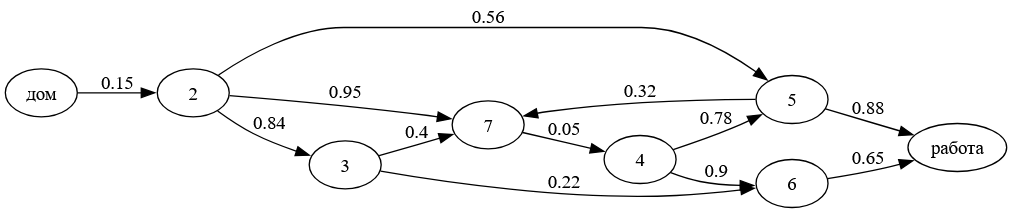

In [1]:
import networkx as nx
import numpy as np

#  Данные маршрутов
edges_data = [
    ('дом', '2', 0.15),
    ('2', '5', 0.56),
    ('2', '7', 0.95),
    ('2', '3', 0.84),
    ('3', '7', 0.40),
    ('3', '6', 0.22),
    ('5', '7', 0.32),
    ('7', '4', 0.05),
    ('4', '5', 0.78),
    ('4', '6', 0.90),
    ('5', 'работа', 0.88),
    ('6', 'работа', 0.65)
]

# Создаем направленный граф
G = nx.DiGraph()

# Заполняем граф, сразу вычисляя нужные веса для алгоритма
for u, v, p_caught in edges_data:
    p_safe = 1.0 - p_caught
    # Вес ребра для Дейкстры: -ln(вероятности проскочить)
    weight = -np.log(p_safe)
    # Сохраняем в граф и вес, и саму вероятность для удобного вывода потом
    G.add_edge(u, v, weight=weight, p_safe=p_safe)

# встроенный алгоритм Дейкстры ищет оптимальный путь
optimal_path = nx.dijkstra_path(G, source='дом', target='работа', weight='weight')

print(" Оптимальный путь:", " ➔ ".join(optimal_path))
print("-" * 40)

total_p_safe = 1.0
for i in range(len(optimal_path) - 1):
    u = optimal_path[i]
    v = optimal_path[i+1]
    p_safe_edge = G[u][v]['p_safe']
    total_p_safe *= p_safe_edge
    print(f"Участок: [{u}] ➔ [{v}] (Вероятность проскочить: {p_safe_edge:.2f})")

print("-" * 40)
print(f"Итоговая вероятность доехать без штрафа: {total_p_safe:.4f} (или {total_p_safe * 100:.2f}%)")

Оптимальный маршрут найден с помощью алгоритма Дейкстры!

Путь: дом ➔ 2 ➔ 5 ➔ работа
----------------------------------------
Участок: [дом] ➔ [2] (Вероятность проскочить: 0.85)
Участок: [2] ➔ [5] (Вероятность проскочить: 0.44)
Участок: [5] ➔ [работа] (Вероятность проскочить: 0.12)
----------------------------------------
Итоговая вероятность доехать без штрафа: 0.0449 (или 4.49%)


In [3]:
import networkx as nx
import numpy as np
import pandas as pd

# ==========================================
# ШАГ 1: Загрузка графа из файла
# ==========================================
# Читаем граф напрямую из файла
G_raw = nx.read_graphml('buildings(1).graphml')

# Изначально узлы называются 'n0', 'n1' и т.д.
# Переименуем их в 1, 2, 3, 4, 5, чтобы они совпадали с индексами матрицы из задания
mapping = {f'n{i}': i + 1 for i in range(5)}
G = nx.relabel_nodes(G_raw, mapping)

# Подготовим атрибуты графа:
# 1. Приведем вес ребра к стандарту 'weight' (в файле он может называться 'e_weight')
# 2. Зададим начальный трафик равным 1 (согласно подсказке из R-кода)
for u, v, data in G.edges(data=True):
    # Безопасно извлекаем вес (если он записан как e_weight)
    if 'e_weight' in data:
        data['weight'] = data.pop('e_weight')
    data['traffic'] = 1

# ==========================================
# ШАГ 2: Матрица переходов студентов
# ==========================================
# Заполняем матрицу потоков P (i -> j)
P = np.array([
    [0,  48, 23, 42, 45],  # Из корпуса 1
    [27, 0,  41, 32, 39],  # Из корпуса 2
    [30, 31, 0,  43, 47],  # Из корпуса 3
    [28, 33, 20, 0,  44],  # Из корпуса 4
    [50, 29, 36, 25, 0]    # Из корпуса 5
])

In [4]:
# ==========================================
# ШАГ 3: Распределение потоков по кратчайшим путям
# ==========================================
nodes = list(G.nodes())

# Проходим по всем парам корпусов
for i in nodes:
    for j in nodes:
        if i != j:
            # Находим кратчайший путь между корпусами i и j
            path = nx.shortest_path(G, source=i, target=j, weight='weight')

            # Количество студентов, идущих по этому маршруту (индексы массивов с 0, а узлы с 1)
            flow = P[i - 1, j - 1]

            # Добавляем этот поток к каждому ребру на найденном маршруте
            for u, v in zip(path[:-1], path[1:]):
                G[u][v]['traffic'] += flow

# Выводим получившийся трафик на графе
print("--- Трафик на переходах ---")
for u, v, data in G.edges(data=True):
    print(f"Переход [{u} ↔ {v}]: {data['traffic']} чел.")

# ==========================================
# ШАГ 4: Поиск лучшего места для кофейни
# ==========================================
print("\n--- РЕЗУЛЬТАТЫ ---")

# 1. Поиск самого загруженного ПЕРЕХОДА (ребра)
best_edge = max(G.edges(data=True), key=lambda x: x[2]['traffic'])
print(f"☕ Лучшее место для кофейни в переходе: между корпусами {best_edge[0]} и {best_edge[1]}")
print(f"   Проходимость: {best_edge[2]['traffic']} человек.")

# 2. Поиск самого загруженного КОРПУСА (узла)
# Считаем сумму трафика всех инцидентных (прилегающих) рёбер для каждого здания
node_traffic = {n: 0 for n in nodes}
for u, v, data in G.edges(data=True):
    node_traffic[u] += data['traffic']
    node_traffic[v] += data['traffic']

best_node = max(node_traffic, key=node_traffic.get)
print(f"🏢 Лучшее здание для открытия кофейни: Корпус {best_node}")
print(f"   Суммарный трафик вокруг: {node_traffic[best_node]} человек.")

--- Трафик на переходах ---
Переход [1 ↔ 2]: 294 чел.
Переход [1 ↔ 4]: 1 чел.
Переход [2 ↔ 3]: 189 чел.
Переход [2 ↔ 4]: 199 чел.
Переход [2 ↔ 5]: 164 чел.
Переход [3 ↔ 4]: 1 чел.
Переход [3 ↔ 5]: 84 чел.
Переход [4 ↔ 5]: 70 чел.

--- РЕЗУЛЬТАТЫ ---
☕ Лучшее место для кофейни в переходе: между корпусами 1 и 2
   Проходимость: 294 человек.
🏢 Лучшее здание для открытия кофейни: Корпус 2
   Суммарный трафик вокруг: 846 человек.


C:\Users\kartohamaster\PycharmProjects\MOIO_py\.venv\Lib\site-packages\networkx\drawing\nx_pylab.py:137: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(self.x, self.y, *args, rotation=self.angle, **kwargs)


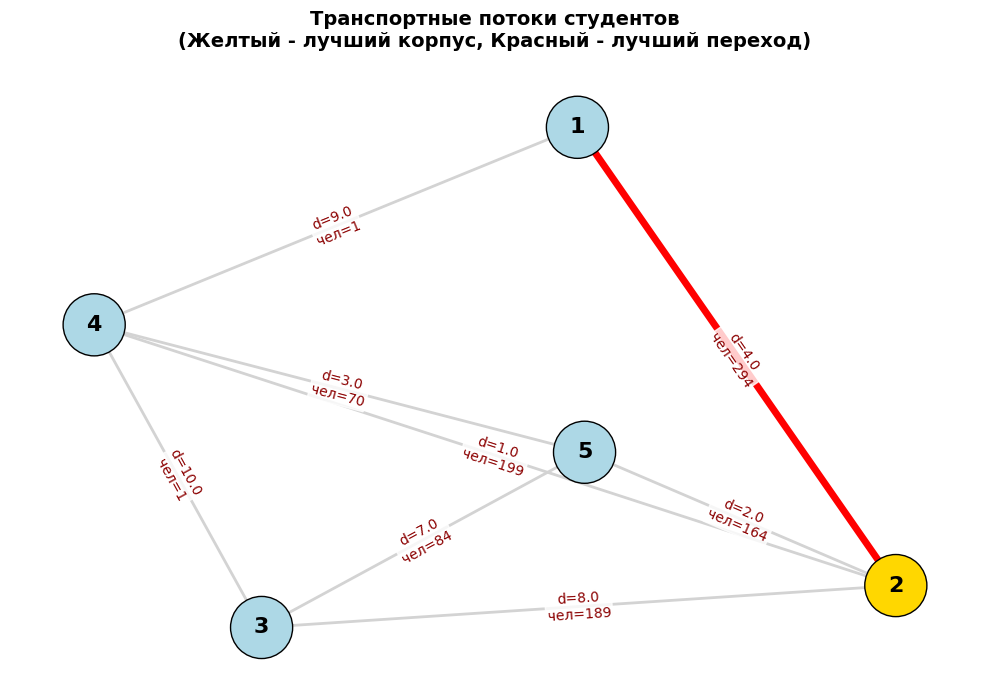

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Выбираем алгоритм расположения узлов (spring_layout хорошо расталкивает узлы)
pos = nx.spring_layout(G, seed=42)

# 1. Отрисовка узлов
# Если узел - это лучший корпус (best_node), красим его в золотой, иначе в светло-синий
node_colors = ['gold' if n == best_node else 'lightblue' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, edgecolors='black')
nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=2)
nx.draw_networkx_edges(G, pos, edgelist=[(best_edge[0], best_edge[1])], edge_color='red', width=5)
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
edge_labels = {
    (u, v): f"d={d['weight']}\nчел={d['traffic']}"
    for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=10,
    font_color='darkred',
    bbox=dict(alpha=0.8, color='white', edgecolor='none', pad=1) # Белый фон под текстом для читаемости
)

plt.title("Транспортные потоки студентов\n(Желтый - лучший корпус, Красный - лучший переход)",
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

Упражнение 27.3 (Соображая на троих) Собираясь на тусовку три товарища с ФСК собрали все деньги, которые у них были (10,40,10) рублей соответственно. На следующее утро возник нетривиальный вопрос о должниках. Считая, что все должны были вложиться поровну определите, кто, кому и сколько должен передать.
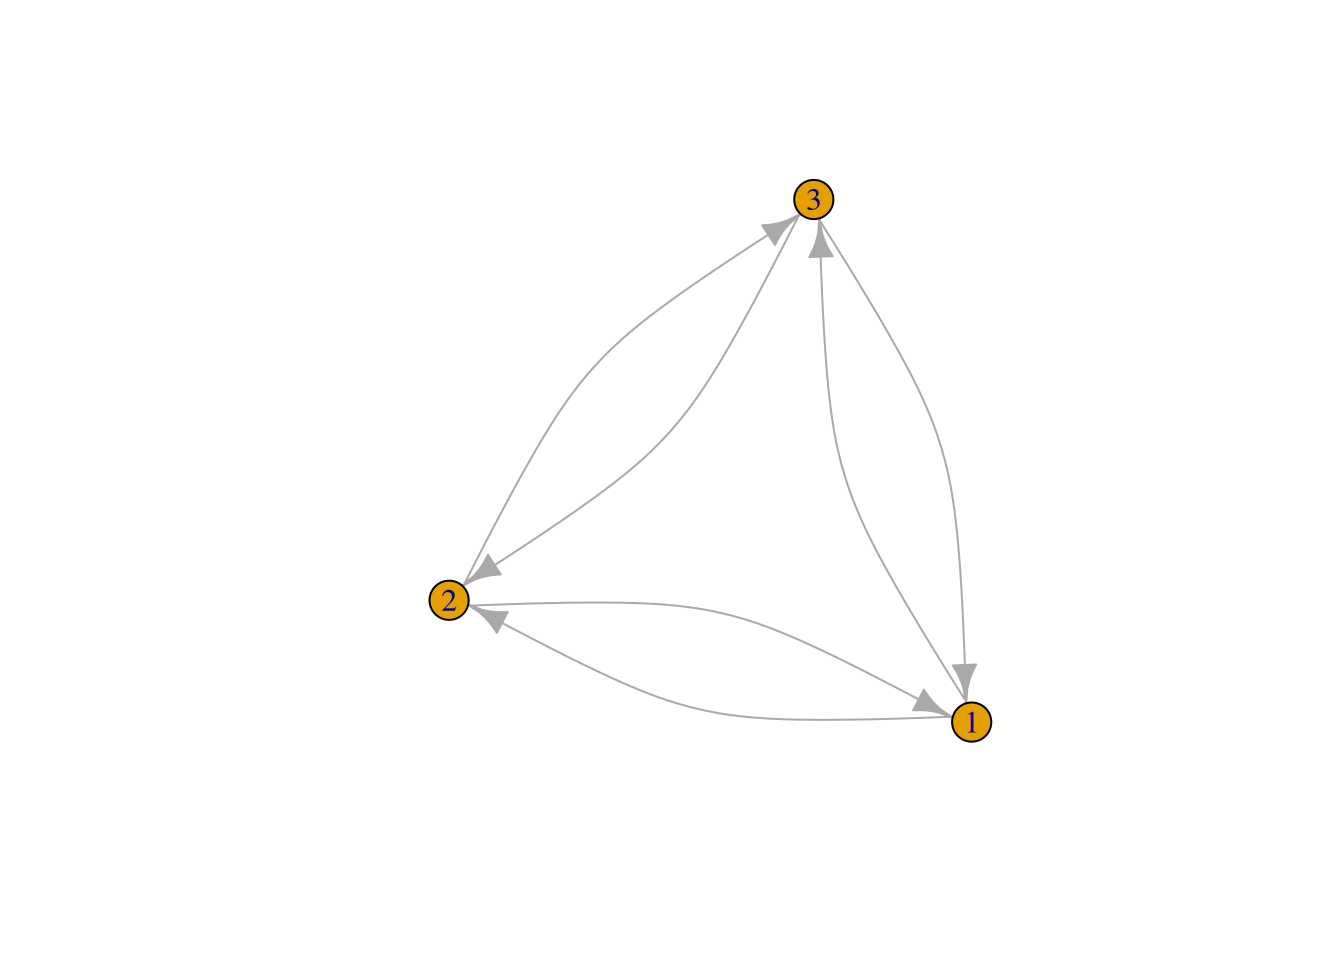
Данную задачу можно сформулировать как задачу поиска максимального потока в сети, если ввести два фиктивных узла: исток (который распределяет всем поровну) и сток (который показывает сколько кто потратил) и тем самым ограничить вместимость (capacity) денежных потоков.
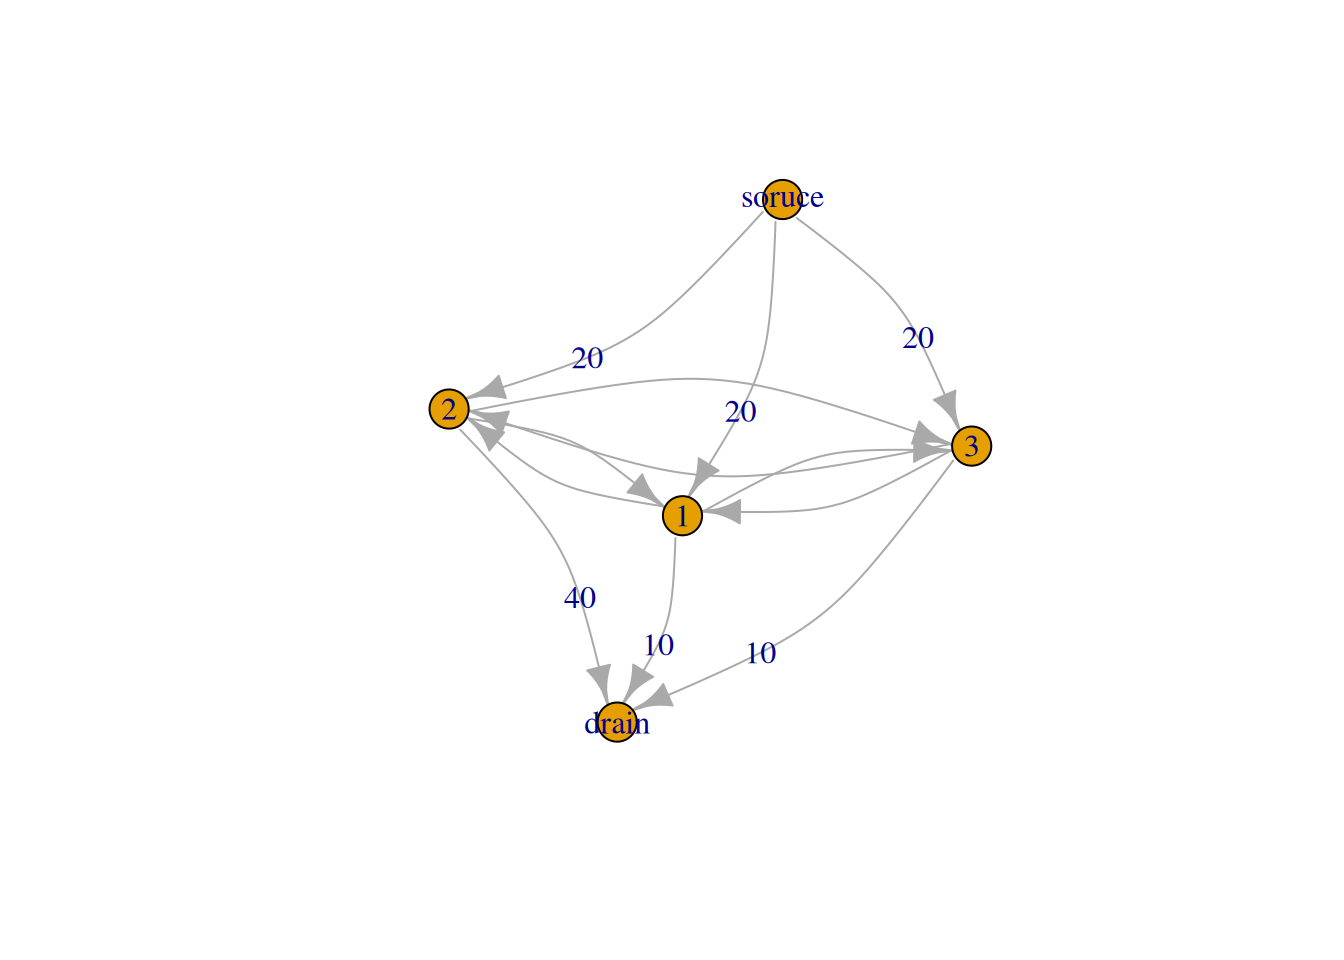

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Данные о расходах
# Студенты 1, 2, 3 потратили 10, 40 и 10 рублей соответственно.
spent = {1: 10, 2: 40, 3: 10}
total_spent = sum(spent.values())
average_share = total_spent // len(spent) # Каждый должен был скинуться по 20 руб.

# 2. Создаем направленный граф сети
G = nx.DiGraph()

# Добавляем узлы (студенты)
students = list(spent.keys())
G.add_nodes_from(students)

# Добавляем все возможные пути перевода денег между студентами.
# capacity ставим бесконечной (или просто очень большим числом),
# так как студенты могут переводить друг другу любые суммы.
for u in students:
    for v in students:
        if u != v:
            G.add_edge(u, v, capacity=float('inf'))

# 3. Вводим фиктивные узлы: Исток (Source) и Сток (Drain)
G.add_node('source')
G.add_node('drain')

# Исток "раздает" каждому ту сумму, которую он ДОЛЖЕН БЫЛ заплатить по справедливости (по 20 руб)
for i in students:
    G.add_edge('source', i, capacity=average_share)

# В Сток "утекает" та сумма, которую каждый РЕАЛЬНО заплатил в баре/кафе (10, 40, 10 руб)
for i, amount in spent.items():
    G.add_edge(i, 'drain', capacity=amount)

# 4. Магия алгоритма: ищем максимальный поток от Истока к Стоку
# Используется алгоритм Эдмондса-Карпа (встроен в networkx по умолчанию)
flow_value, flow_dict = nx.maximum_flow(G, 'source', 'drain')

# ==========================================
# 5. Обработка результатов и отрисовка
# ==========================================
print(f"💰 Общий бюджет тусовки: {total_spent} руб. (по {average_share} руб. с каждого)")
print("-" * 40)

# Создаем новый граф только для визуализации реальных долгов (без фиктивных узлов)
Debts = nx.DiGraph()

for u in students:
    for v in students:
        if u != v:
            # Смотрим, потекли ли деньги от u к v в нашем решении
            debt = flow_dict[u][v]
            if debt > 0:
                print(f"✅ Студент {u} должен перевести Студенту {v}: {debt} руб.")
                Debts.add_edge(u, v, weight=debt)

💰 Общий бюджет тусовки: 60 руб. (по 20 руб. с каждого)
----------------------------------------
✅ Студент 1 должен перевести Студенту 2: 10 руб.
✅ Студент 3 должен перевести Студенту 2: 10 руб.


In [8]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# 1. Подготовка данных
# Формат: (Название процесса, [Предшественники], Длительность)
tasks_data = [
    ("A", [], 1),
    ("B", [], 2),
    ("C", ["A"], 1),
    ("D", ["C"], 2),
    ("E", ["B", "C"], 6),
    ("F", ["D"], 10),
    ("G", ["F"], 3),
    ("H", ["G"], 1),
    ("I", ["F"], 1),
    ("J", ["E", "H"], 5),
    ("K", ["I"], 2),
    ("L", ["F", "J"], 1),
    ("M", ["F"], 2),
    ("N", ["L", "M"], 4),
    ("O", ["G", "J"], 2),
    ("P", ["O"], 2),
    ("Q", ["I", "P"], 1),
    ("R", ["P"], 7),
    ("S", ["I", "N"], 7),
    ("T", ["S"], 3)
]

# 2. Создание направленного графа зависимостей
G = nx.DiGraph()

# Добавляем фиктивные узлы Старта и Конца для удобства расчетов
G.add_node("Start", duration=0)
G.add_node("End", duration=0)

# Добавляем все работы как узлы
for task, preds, duration in tasks_data:
    G.add_node(task, duration=duration)
    # Если предшественников нет, связываем со Стартом
    if not preds:
        G.add_edge("Start", task)
    # Иначе связываем с предшественниками
    for p in preds:
        G.add_edge(p, task)

# Все работы, у которых нет последователей, привязываем к Концу
for node in list(G.nodes()):
    if G.out_degree(node) == 0 and node != "End":
        G.add_edge(node, "End")

# ==========================================
# 3. Расчет критического пути (CPM)
# ==========================================

# ПРЯМОЙ ПРОХОД (Forward Pass) - Считаем раннее начало (ES) и раннее окончание (EF)
# Топологическая сортировка гарантирует, что мы посетим узлы в правильном порядке
for node in nx.topological_sort(G):
    if node == "Start":
        G.nodes[node]['es'] = 0
        G.nodes[node]['ef'] = 0
    else:
        # ES = максимум из EF всех предшественников
        predecessors = list(G.predecessors(node))
        es = max([G.nodes[p]['ef'] for p in predecessors])
        G.nodes[node]['es'] = es
        G.nodes[node]['ef'] = es + G.nodes[node]['duration']

# Общая длительность проекта - это EF конечного узла
project_duration = G.nodes["End"]['ef']

# ОБРАТНЫЙ ПРОХОД (Backward Pass) - Считаем позднее начало (LS) и позднее окончание (LF)
# Идем в обратном порядке
for node in reversed(list(nx.topological_sort(G))):
    if node == "End":
        G.nodes[node]['lf'] = project_duration
        G.nodes[node]['ls'] = project_duration
    else:
        # LF = минимум из LS всех последователей
        successors = list(G.successors(node))
        lf = min([G.nodes[s]['ls'] for s in successors])
        G.nodes[node]['lf'] = lf
        G.nodes[node]['ls'] = lf - G.nodes[node]['duration']

# Вычисляем резерв времени (Slack) и собираем критический путь
critical_path = []
results = []

for node in nx.topological_sort(G):
    if node not in ["Start", "End"]:
        # Резерв = Позднее начало - Раннее начало
        slack = G.nodes[node]['ls'] - G.nodes[node]['es']
        G.nodes[node]['slack'] = slack

        # Если резерв равен 0, работа лежит на критическом пути
        is_critical = slack == 0
        if is_critical:
            critical_path.append(node)

        results.append({
            "Процесс": node,
            "Длительность": G.nodes[node]['duration'],
            "Раннее начало (ES)": G.nodes[node]['es'],
            "Раннее окончание (EF)": G.nodes[node]['ef'],
            "Позднее начало (LS)": G.nodes[node]['ls'],
            "Позднее окончание (LF)": G.nodes[node]['lf'],
            "Резерв (Slack)": slack,
            "Критическая?": "Да" if is_critical else "Нет"
        })

# ==========================================
# 4. Вывод результатов
# ==========================================

print(f"⏱️ Общая длительность строительства: {project_duration} дней")
print(f"🔥 Критический путь: {' ➔ '.join(critical_path)}\n")

# Красиво выводим таблицу с помощью pandas
df_schedule = pd.DataFrame(results)
display(df_schedule)

⏱️ Общая длительность строительства: 38 дней
🔥 Критический путь: A ➔ C ➔ D ➔ F ➔ G ➔ H ➔ J ➔ L ➔ N ➔ S ➔ T



,Процесс,Длительность,Раннее начало (ES),Раннее окончание (EF),Позднее начало (LS),Позднее окончание (LF),Резерв (Slack),Критическая?
0,A,1,0,1,0,1,0,Да
1,B,2,0,2,10,12,10,Нет
2,C,1,1,2,1,2,0,Да
3,D,2,2,4,2,4,0,Да
4,E,6,2,8,12,18,10,Нет
5,F,10,4,14,4,14,0,Да
6,G,3,14,17,14,17,0,Да
7,I,1,14,15,27,28,13,Нет
8,M,2,14,16,22,24,8,Нет
9,H,1,17,18,17,18,0,Да
